# Experiments — Cast Defect Classification

Imports from `src/`, settings in `configs/config.yaml`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.utils import load_config, get_device, set_seed, resolve_path
from src.dataset import get_dataloaders
from src.train_engine import Trainer
from src.evaluate import evaluate_model, collect_predictions
from src.inference import load_model_for_inference, predict_image
from src.visualization import save_all_training_plots, save_confusion_matrix_plot
import json

config = load_config(ROOT / "configs/config.yaml")
set_seed(config["random_seed"])
device = get_device(config)
print("Device:", device)

Device: mps


## Load data

In [2]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(config, device)
print("Classes:", class_names)
print("Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset), "Test:", len(test_loader.dataset))

Classes: ['defect', 'normal']
Train: 5827 Val: 727 Test: 731


## Training (optional)

Set `RUN_TRAINING = True` or run `python scripts/train.py` in terminal.

In [5]:
RUN_TRAINING = True

if RUN_TRAINING:
    trainer = Trainer(config, train_loader, val_loader, class_names, device)
    history = trainer.train()
    save_all_training_plots(history, config)
else:
    hist_path = resolve_path(config["evaluation"]["metrics_file"]).parent / "training_history.json"
    history = json.load(open(hist_path)) if hist_path.exists() else {}
    print("Loaded history:", bool(history))


Epoch 20/20


train_loss=0.2430 val_loss=0.2703 | train_acc=91.73% val_acc=89.68%
Early stopping (patience=5)

Done. Best model: /Users/user/PycharmProjects/Learning/AI/projects/cnn-cast-defect-classification/outputs/models/best_model.pth


## 8 visualizations

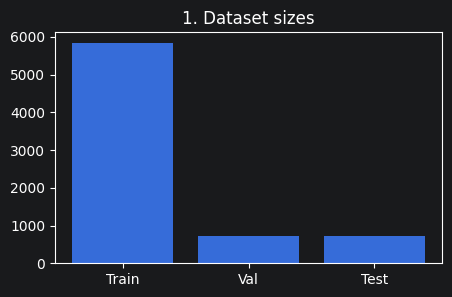

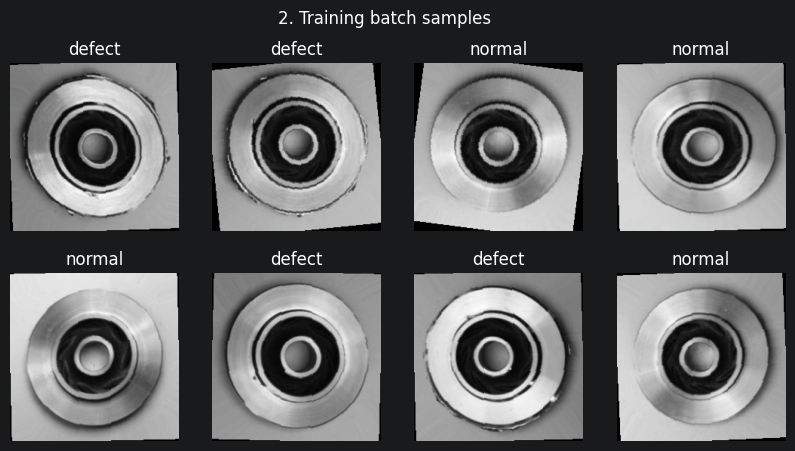

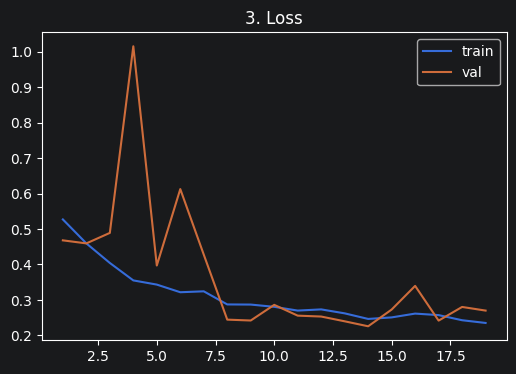

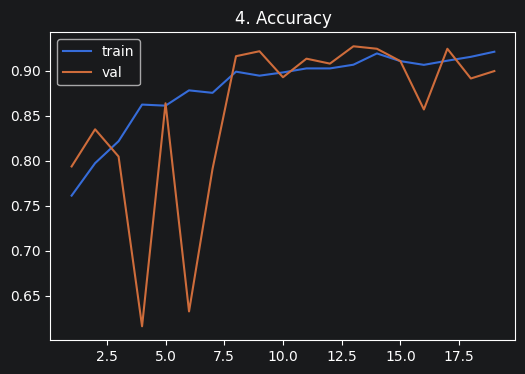

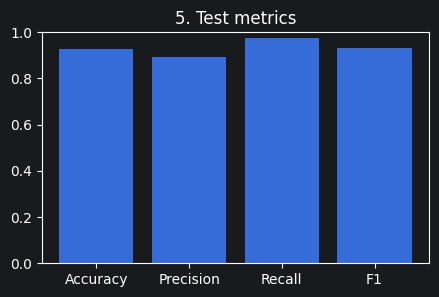

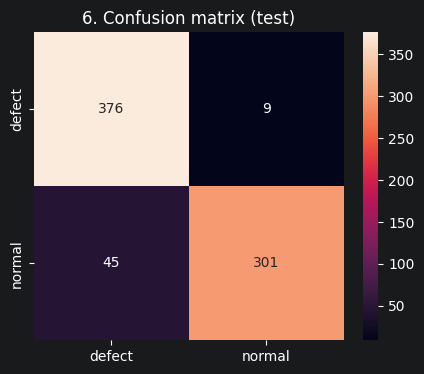

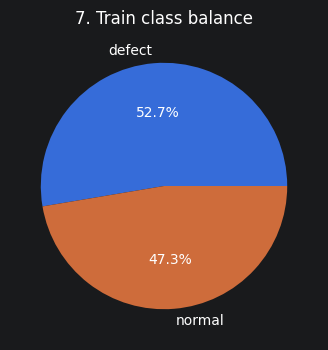

In [4]:
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def show_img(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0) * STD + MEAN
    return np.clip(img, 0, 1)

# 1. Dataset sizes
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Train", "Val", "Test"], [len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)])
ax.set_title("1. Dataset sizes")
plt.show()

# 2. Sample images
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lbl in zip(axes.flat, imgs[:8], labels[:8]):
    ax.imshow(show_img(img))
    ax.set_title(class_names[lbl])
    ax.axis("off")
fig.suptitle("2. Training batch samples")
plt.show()

# 3-4. Loss and accuracy curves
if history.get("train_loss"):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(ep, history["train_loss"], label="train")
    ax.plot(ep, history["val_loss"], label="val")
    ax.set_title("3. Loss")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(ep, history["train_accuracy"], label="train")
    ax.plot(ep, history["val_accuracy"], label="val")
    ax.set_title("4. Accuracy")
    ax.legend()
    plt.show()
else:
    print("No history — run scripts/train.py first")

# 5-6. Evaluation + confusion matrix
model, class_names, device = load_model_for_inference(config, device=device)
metrics, y_true, y_pred = evaluate_model(model, test_loader, device, class_names, config)

fig, ax = plt.subplots(figsize=(5, 3))
names = ["Accuracy", "Precision", "Recall", "F1"]
vals = [metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1_score"]]
ax.bar(names, vals)
ax.set_ylim(0, 1)
ax.set_title("5. Test metrics")
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", ax=ax, xticklabels=class_names, yticklabels=class_names)
ax.set_title("6. Confusion matrix (test)")
plt.show()

# 7. Class distribution in train
counts = np.bincount(train_loader.dataset.targets, minlength=len(class_names))
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(counts, labels=class_names, autopct="%1.1f%%")
ax.set_title("7. Train class balance")
plt.show()

## 1. Dataset Overview

See `docs/dataset_documentation.md` for source, size, and class distribution.

In [ ]:
# Dataset statistics from label.csv
import csv
from collections import Counter
from pathlib import Path
labels_path = ROOT / 'data/label.csv'
counts = Counter()
with labels_path.open(newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        counts[row['choice'].strip().lower()] += 1
print('Labeled images:', sum(counts.values()))
print('Class distribution:', dict(counts))


## 2. Data Preprocessing

- Resize to 224×224
- ImageNet normalization
- Train/val/test split 80/10/10 (stratified by class)
- Augmentation (train): horizontal flip, rotation ±10°

## 3. Custom CNN Architecture

See `src/model.py` — 3× Conv blocks (32→64→96), BatchNorm, MaxPool, Dropout, Linear classifier.

## 4. Training Results

Loss/accuracy curves and test metrics are generated above and saved under `outputs/`.

## 5. Hyperparameter Tuning

Run `python scripts/run_hyperparameter_tuning.py` then display results:

In [ ]:
import pandas as pd
tuning_csv = ROOT / 'outputs/tuning/tuning_results.csv'
if tuning_csv.exists():
    display(pd.read_csv(tuning_csv))
    from IPython.display import Image, display
    img = ROOT / 'outputs/tuning/tuning_comparison.png'
    if img.exists():
        display(Image(filename=str(img)))
else:
    print('Run: python scripts/run_hyperparameter_tuning.py')


## 6. Baseline Comparison (ResNet18 transfer learning)

In [ ]:
import pandas as pd
cmp = ROOT / 'outputs/baseline/model_comparison.csv'
if cmp.exists():
    display(pd.read_csv(cmp))
    from IPython.display import Image, display
    display(Image(filename=str(ROOT / 'outputs/baseline/model_comparison.png')))
    display(Image(filename=str(ROOT / 'outputs/baseline/resnet18_confusion_matrix.png')))
else:
    print('Run: python scripts/train_baseline.py')


## 7. Feature Extraction Analysis

**Conv block 1** captures edges and local texture. **Conv block 2** combines patterns into larger defect-like regions. **Conv block 3** highlights semantically rich areas before classification.

In [ ]:
from IPython.display import Image, display
for label in ('normal', 'defect'):
    for block in ('conv1', 'conv2', 'conv3'):
        p = ROOT / f'outputs/feature_maps/{label}_{block}.png'
        if p.exists():
            print(label, block)
            display(Image(filename=str(p), width=280))
        else:
            print('Missing', p, '— run scripts/generate_analysis_assets.py')


## 8. Learned Filter Analysis

First-layer filters show edge and blob detectors learned from cast surface images.

In [ ]:
from IPython.display import Image, display
p = ROOT / 'outputs/filters/conv1_filters.png'
display(Image(filename=str(p))) if p.exists() else print('Run generate_analysis_assets.py')


## 9. Grad-CAM Analysis

Grad-CAM shows which regions support the predicted class (defect vs normal).

In [ ]:
from IPython.display import Image, display
for p in [ROOT / 'outputs/gradcam/defect_gradcam.png', ROOT / 'outputs/gradcam/normal_gradcam.png']:
    if p.exists():
        display(Image(filename=str(p), width=500))
    else:
        print('Missing', p)


## 10. Deployment Evidence

Streamlit app + static previews in `docs/screenshots/`.

In [ ]:
from IPython.display import Image, display
shots = sorted((ROOT / 'docs/screenshots').glob('*.png'))
for p in shots:
    print(p.name)
    display(Image(filename=str(p), width=520))
